In [1]:
from datasets import load_dataset

dataset = load_dataset("pietrolesci/pubmed-200k-rct")
dataset


c:\Dev\Elective\elective_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Dev\Elective\elective_env\lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\abhik\.cache\huggingface\hub\datasets--pietrolesci--pubmed-200k-rct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer 

DatasetDict({
    train: Dataset({
        features: ['labels', 'text', 'uid'],
        num_rows: 2211861
    })
    validation: Dataset({
        features: ['labels', 'text', 'uid'],
        num_rows: 28932
    })
    test: Dataset({
        features: ['labels', 'text', 'uid'],
        num_rows: 29493
    })
})

In [2]:
dataset["train"].features



{'labels': ClassLabel(names=['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS']),
 'text': Value('string'),
 'uid': Value('int64')}

In [3]:
label_names = dataset["train"].features["labels"].names
label_names



['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS']

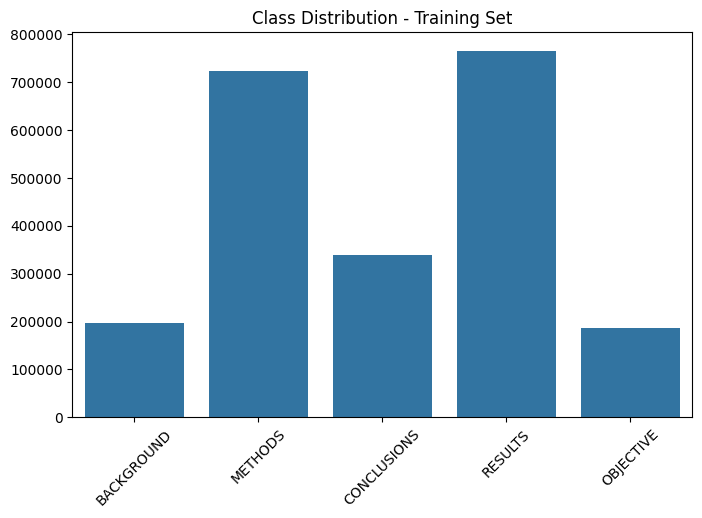

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

labels = dataset["train"]["labels"]
count = Counter(labels)

plt.figure(figsize=(8,5))
sns.barplot(
    x=[label_names[i] for i in count.keys()],
    y=list(count.values())
)
plt.xticks(rotation=45)
plt.title("Class Distribution - Training Set")
plt.show()


In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))


Using device: cuda
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU


In [1]:
from datasets import load_dataset

# Load dataset
print("Loading dataset...")
dataset = load_dataset("pietrolesci/pubmed-200k-rct")

# Create training subset (150k samples)
print("Creating 150k subset...")
train_dataset = dataset["train"].shuffle(seed=42).select(range(150000))

# Use full validation set (or subset if needed)
val_dataset = dataset["validation"]

# Extract label information
label_names = dataset["train"].features["labels"].names
num_labels = len(label_names)

print(f"\nTraining samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Number of labels: {num_labels}")
print(f"Label names: {label_names}")

c:\Dev\Elective\elective_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset...


Creating 150k subset...

Training samples: 150000
Validation samples: 28932
Number of labels: 5
Label names: ['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS']


tokenizer

In [3]:
from transformers import BertTokenizer
import torch

# Initialize tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenization function - DON'T remove labels!
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

# Tokenize datasets (keep labels column!)
print("Tokenizing training data...")
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['text']  # Only remove 'text', keep 'labels'
)

print("Tokenizing validation data...")
tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['text']  # Only remove 'text', keep 'labels'
)

# Set format for PyTorch
tokenized_train.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
tokenized_val.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print("\n✅ Tokenization complete!")
print(f"Train columns: {tokenized_train.column_names}")
print(f"Val columns: {tokenized_val.column_names}")

Tokenizing training data...


Map: 100%|██████████| 150000/150000 [00:10<00:00, 14097.02 examples/s]


Tokenizing validation data...


Map: 100%|██████████| 28932/28932 [00:01<00:00, 19896.69 examples/s]


✅ Tokenization complete!
Train columns: ['labels', 'uid', 'input_ids', 'token_type_ids', 'attention_mask']
Val columns: ['labels', 'uid', 'input_ids', 'token_type_ids', 'attention_mask']


data loaders

In [4]:
from torch.utils.data import DataLoader

# Hyperparameters
BATCH_SIZE = 32
NUM_WORKERS = 2  # Adjust based on your CPU cores

# Create DataLoaders
train_loader = DataLoader(
    tokenized_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    tokenized_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Batch size: {BATCH_SIZE}")

Training batches: 4688
Validation batches: 905
Batch size: 32


model

In [7]:
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.3.2 --no-cache-dir

     ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
      --------------------------------------- 0.2/9.3 MB 6.9 MB/s eta 0:00:02
     ---- ----------------------------------- 1.0/9.3 MB 12.5 MB/s eta 0:00:01
     ------ --------------------------------- 1.5/9.3 MB 12.0 MB/s eta 0:00:01
     ----------- ---------------------------- 2.7/9.3 MB 15.4 MB/s eta 0:00:01
     ---------------- ----------------------- 3.8/9.3 MB 17.3 MB/s eta 0:00:01
     --------------------- ------------------ 5.1/9.3 MB 18.1 MB/s eta 0:00:01
     --------------------------- ------------ 6.4/9.3 MB 20.4 MB/s eta 0:00:01
     --------------------------------- ------ 7.8/9.3 MB 20.8 MB/s eta 0:00:01
     ---------------------------------------  9.1/9.3 MB 21.6 MB/s eta 0:00:01
     ---------------------------------------- 9.3/9.3 MB 21.9 MB/s eta 0:00:00
     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
     -- ------------------------------------- 1.2/15.8 MB 37.3 MB/s 


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from transformers import BertModel
import torch.nn as nn
import torch

class BertClassifier(nn.Module):
    def __init__(self, num_labels=5, dropout=0.3):
        super(BertClassifier, self).__init__()
        
        # Load pre-trained BERT
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout)
        
        # Classification head
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)
    
    def forward(self, input_ids, attention_mask):
        # Get BERT outputs
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        # Use [CLS] token representation
        pooled_output = outputs.pooler_output
        
        # Apply dropout
        pooled_output = self.dropout(pooled_output)
        
        # Get logits
        logits = self.classifier(pooled_output)
        
        return logits

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BertClassifier(num_labels=num_labels)
model = model.to(device)

print(f"✅ Model initialized on {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 918.10it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model initialized on cuda
Total parameters: 109,486,085
Trainable parameters: 109,486,085


In [11]:
from torch.optim import AdamW
from tqdm.auto import tqdm

# Hyperparameters
LEARNING_RATE = 2e-5
EPOCHS = 3

# Optimizer and loss
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

print("✅ Training setup complete!")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Epochs: {EPOCHS}")
print(f"Optimizer: AdamW")
print(f"Loss function: CrossEntropyLoss")

✅ Training setup complete!
Learning rate: 2e-05
Epochs: 3
Optimizer: AdamW
Loss function: CrossEntropyLoss


In [12]:
import numpy as np

def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader, desc="Training")
    
    for batch in progress_bar:
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        logits = model(input_ids, attention_mask)
        
        # Calculate loss
        loss = criterion(logits, labels)
        
        # Backward pass
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        # Track metrics
        total_loss += loss.item()
        predictions = torch.argmax(logits, dim=-1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100 * correct / total:.2f}%'
        })
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy

def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            # Forward pass
            logits = model(input_ids, attention_mask)
            
            # Calculate loss
            loss = criterion(logits, labels)
            
            # Track metrics
            total_loss += loss.item()
            predictions = torch.argmax(logits, dim=-1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    
    avg_loss = total_loss / len(val_loader)
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy

# Training loop
print("🚀 Starting training...\n")

for epoch in range(EPOCHS):
    print(f"{'='*60}")
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"{'='*60}")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Print epoch summary
    print(f"\n📊 Epoch {epoch + 1} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print()

print("✅ Training complete!")

🚀 Starting training...

Epoch 1/3


Training:   0%|          | 0/4688 [00:00<?, ?it/s]c:\Dev\Elective\elective_env\lib\site-packages\transformers\integrations\sdpa_attention.py:92: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
Validation: 100%|██████████| 905/905 [02:33<00:00,  5.91it/s]



📊 Epoch 1 Summary:
  Train Loss: 0.4153 | Train Acc: 84.89%
  Val Loss:   0.3546 | Val Acc:   87.08%

Epoch 2/3


Validation: 100%|██████████| 905/905 [02:32<00:00,  5.95it/s]



📊 Epoch 2 Summary:
  Train Loss: 0.3291 | Train Acc: 87.94%
  Val Loss:   0.3437 | Val Acc:   87.29%

Epoch 3/3


Validation: 100%|██████████| 905/905 [02:32<00:00,  5.94it/s]



📊 Epoch 3 Summary:
  Train Loss: 0.2714 | Train Acc: 89.90%
  Val Loss:   0.3646 | Val Acc:   86.74%

✅ Training complete!


In [13]:
# Save model
model_path = "bert_pubmed_model.pth"

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'label_names': label_names,
    'num_labels': num_labels
}, model_path)

print(f"✅ Model saved to {model_path}")

✅ Model saved to bert_pubmed_model.pth


Evaluating: 100%|██████████| 905/905 [02:31<00:00,  5.99it/s]



CLASSIFICATION REPORT
              precision    recall  f1-score   support

  BACKGROUND     0.6418    0.7480    0.6908      2575
 CONCLUSIONS     0.8001    0.8594    0.8287      4396
     METHODS     0.9410    0.9321    0.9365      9559
   OBJECTIVE     0.7824    0.6078    0.6841      2425
     RESULTS     0.9141    0.9030    0.9085      9977

    accuracy                         0.8674     28932
   macro avg     0.8159    0.8101    0.8097     28932
weighted avg     0.8704    0.8674    0.8674     28932



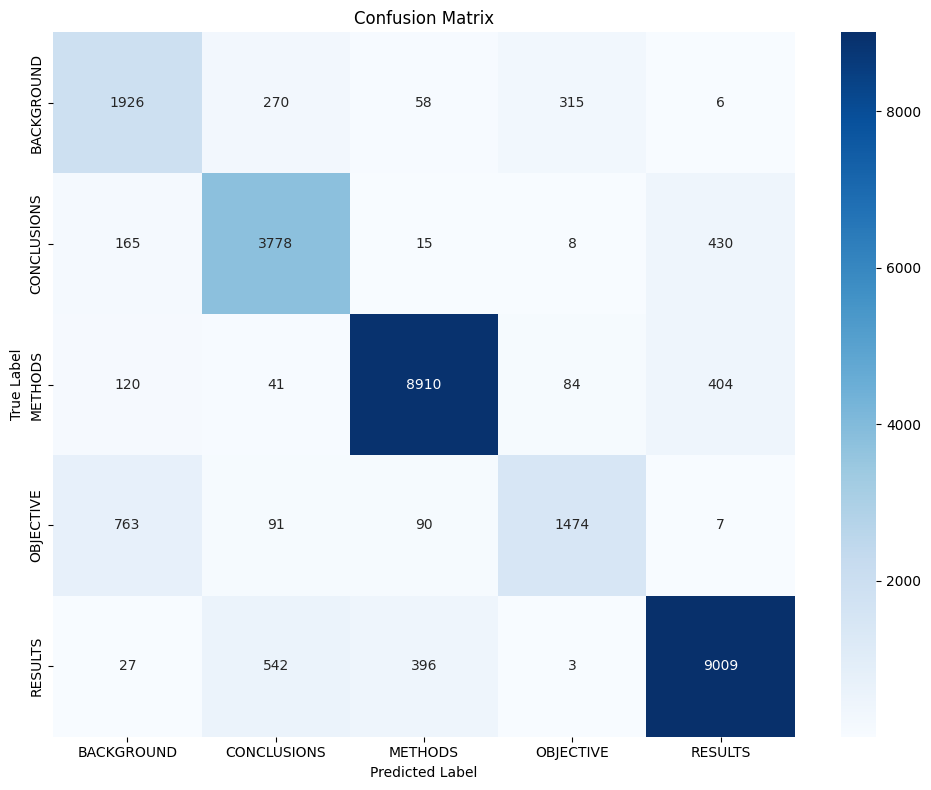

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, val_loader, device, label_names):
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            logits = model(input_ids, attention_mask)
            predictions = torch.argmax(logits, dim=-1)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Print classification report
    print("\n" + "="*60)
    print("CLASSIFICATION REPORT")
    print("="*60)
    print(classification_report(
        all_labels,
        all_predictions,
        target_names=label_names,
        digits=4
    ))
    
    # Plot confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names
    )
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Run evaluation
evaluate_model(model, val_loader, device, label_names)

In [15]:
def predict_text(text, model, tokenizer, device, label_names):
    """
    Predict the class label for a given text.
    """
    model.eval()
    
    # Tokenize input
    inputs = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )
    
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)
    
    # Get prediction
    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probabilities = torch.softmax(logits, dim=-1)
        confidence, predicted_class = torch.max(probabilities, dim=-1)
    
    predicted_label = label_names[predicted_class.item()]
    confidence_score = confidence.item()
    
    return predicted_label, confidence_score

# Test the inference function
test_text = "We conducted a randomized controlled trial with 200 participants."

predicted_label, confidence = predict_text(
    test_text,
    model,
    tokenizer,
    device,
    label_names
)

print(f"\n{'='*60}")
print(f"Input Text: {test_text}")
print(f"{'='*60}")
print(f"Predicted Label: {predicted_label}")
print(f"Confidence: {confidence*100:.2f}%")
print(f"{'='*60}")


Input Text: We conducted a randomized controlled trial with 200 participants.
Predicted Label: METHODS
Confidence: 95.48%


In [16]:
# Test different sentence types
test_sentences = [
    "The results showed a significant improvement in patient outcomes.",
    "This study aims to investigate the effects of meditation on stress.",
    "In conclusion, our findings suggest that early intervention is crucial.",
    "Participants were randomly assigned to treatment or control groups.",
    "Previous research has demonstrated the importance of sleep quality."
]

for text in test_sentences:
    label, conf = predict_text(text, model, tokenizer, device, label_names)
    print(f"Text: {text[:60]}...")
    print(f"→ Predicted: {label} ({conf*100:.2f}%)\n")

Text: The results showed a significant improvement in patient outc...
→ Predicted: CONCLUSIONS (52.14%)

Text: This study aims to investigate the effects of meditation on ...
→ Predicted: BACKGROUND (59.51%)

Text: In conclusion, our findings suggest that early intervention ...
→ Predicted: CONCLUSIONS (99.36%)

Text: Participants were randomly assigned to treatment or control ...
→ Predicted: METHODS (97.36%)

Text: Previous research has demonstrated the importance of sleep q...
→ Predicted: BACKGROUND (67.84%)

